In [1]:
import os
import pandas as pd
import polars as pl 
from dotenv import load_dotenv
from pymongo import MongoClient 
import missingno as msno

1. Chargement et instance du dataset

In [2]:
df = pl.read_csv("../data/listingsParis.csv")

2. Nettoyage NAN

<Axes: >

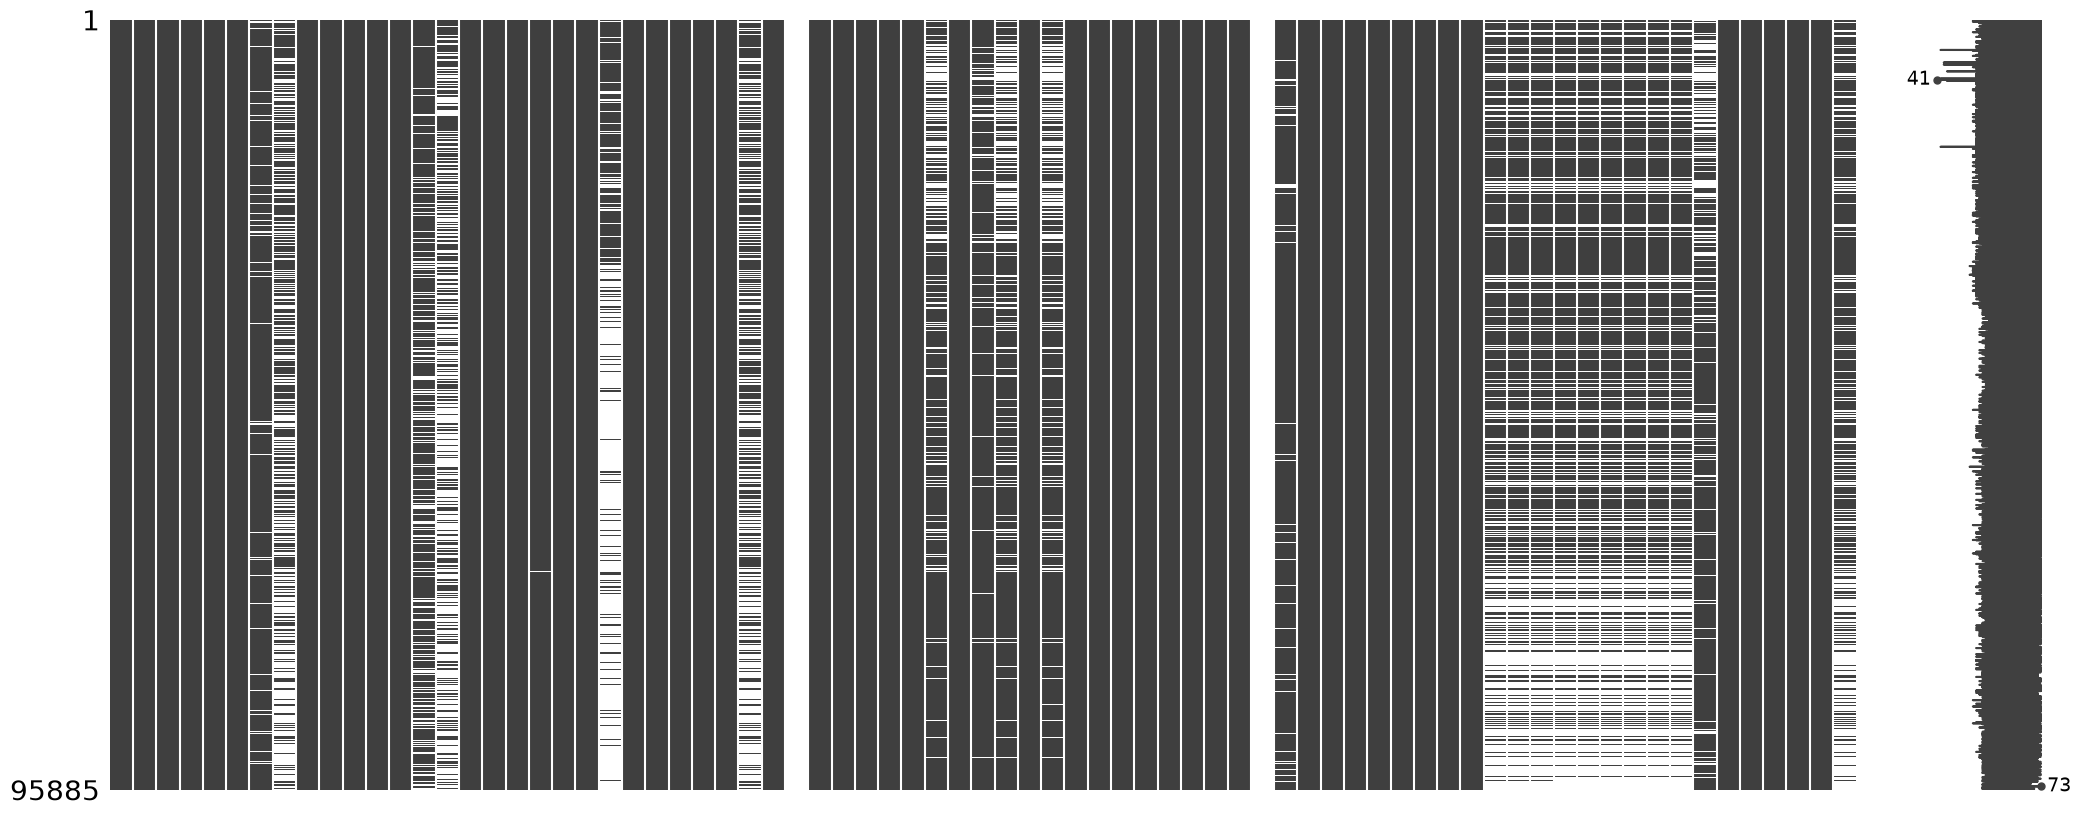

In [3]:
def clean(df:pl.DataFrame):
    return df.with_columns(
        pl.col(pl.String).str.strip_chars().replace("", None)
        )

df = clean(df)

df.head(2)

msno.matrix(df.to_pandas())

3.Mapping

In [4]:
FIELD_MAPPING = {
    "availability": [
        "availability_30",
        "availability_60",
        "availability_90",
        "availability_365",
        "has_availability",
        "calendar_updated",
        "instant_bookable",
    ],
    "host": [
        "calculated_host_listings_count",
        "calculated_host_listings_count_entire_homes",
        "calculated_host_listings_count_private_rooms",
        "calculated_host_listings_count_shared_rooms",
        "host_about",
        "host_acceptance_rate",
        "host_has_profile_pic",
        "host_id",
        "host_identity_verified",
        "host_is_superhost",
        "host_listings_count",
        "host_location",
        "host_name",
        "host_neighbourhood",
        "host_picture_url",
        "host_response_rate",
        "host_response_time",
        "host_since",
        "host_thumbnail_url",
        "host_total_listings_count",
        "host_url",
        "host_verifications",
    ],
    "neighbourhood": [
        "latitude",
        "longitude",
        "neighbourhood",
        "neighbourhood_cleansed",
        "neighbourhood_group_cleansed",
        "neighborhood_overview",
    ],
    "night": [
        "maximum_maximum_nights",
        "maximum_minimum_nights",
        "maximum_nights",
        "maximum_nights_avg_ntm",
        "minimum_maximum_nights",
        "minimum_minimum_nights",
        "minimum_nights",
        "minimum_nights_avg_ntm",
    ],
    "property": [
        "accommodates",
        "amenities",
        "bathrooms",
        "bathrooms_text",
        "bedrooms",
        "beds",
        "property_type",
        "room_type",
    ],
    "review": [
        "first_review",
        "last_review",
        "number_of_reviews",
        "number_of_reviews_l30d",
        "number_of_reviews_ltm",
        "review_scores_accuracy",
        "review_scores_checkin",
        "review_scores_cleanliness",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_rating",
        "review_scores_value",
        "reviews_per_month",
    ],
    "scraping": [
        "calendar_last_scraped",
        "last_scraped",
        "scrape_id",
        "source",
    ],
    "root": [
        "description",
        "id",
        "license",
        "listing_url",
        "name",
        "picture_url",
        "price",
    ],
}

5. Casting

In [5]:
TYPE_MAPPING = {
    "Int64": [
        "id",
        "scrape_id",
        "host_id",
        "accommodates",
        "minimum_nights",
        "maximum_nights",
        "minimum_minimum_nights",
        "maximum_minimum_nights",
        "minimum_maximum_nights",
        "maximum_maximum_nights",
        "availability_30",
        "availability_60",
        "availability_90",
        "availability_365",
        "number_of_reviews",
        "number_of_reviews_ltm",
        "number_of_reviews_l30d",
        "calculated_host_listings_count",
        "calculated_host_listings_count_entire_homes",
        "calculated_host_listings_count_private_rooms",
        "calculated_host_listings_count_shared_rooms",
        "bedrooms",
        "beds",
        "host_listings_count",
        "host_total_listings_count",
    ],
    "Float64Specific": [
        "price",
        "host_response_rate",
        "host_acceptance_rate", 
    ],
    "Float64": [
        "latitude",
        "longitude",
        "minimum_nights_avg_ntm",
        "maximum_nights_avg_ntm",
        "bathrooms",
        "reviews_per_month",
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value",
    ],
    "Boolean": [
        "host_is_superhost",
        "host_has_profile_pic",
        "host_identity_verified",
        "has_availability",
        "instant_bookable",
    ],
    "Date": [
        "last_scraped",
        "host_since",
        "calendar_updated",
        "calendar_last_scraped",
        "first_review",
        "last_review",
    ],
    "String": [
        "listing_url",
        "source",
        "name",
        "description",
        "neighborhood_overview",
        "picture_url",
        "host_url",
        "host_name",
        "host_location",
        "host_about",
        "host_response_time",
        "host_thumbnail_url",
        "host_picture_url",
        "host_neighbourhood", 
        "neighbourhood",
        "neighbourhood_cleansed",
        "neighbourhood_group_cleansed",
        "property_type",
        "room_type",
        "bathrooms_text",
        "license",
    ],
    "List": [
        "amenities",
        "host_verifications",
    ]
}

def cast(df:pl.DataFrame):
    df = df.with_columns(
        *[pl.col(c).str.replace_all(r"[$,%]", "").cast(pl.Float64, strict=False) for c in TYPE_MAPPING["Float64Specific"]],
        *[pl.col(c).cast(pl.Int64, strict=False) for c in TYPE_MAPPING["Int64"]],
        *[pl.col(c).cast(pl.Float64, strict=False) for c in TYPE_MAPPING["Float64"]],
        *[pl.col(c).str.to_date() for c in TYPE_MAPPING["Date"]],
        *[pl.col(c).str.replace_all("'", '"').str.replace_all("None", "null").str.json_decode(dtype=pl.List(pl.String)) for c in TYPE_MAPPING["List"]],
        *[(pl.col(c) == "t").alias(c) for c in TYPE_MAPPING["Boolean"]],
    )
    return df

df = cast(df)

df.head()

ComputeError: error deserializing JSON: json parsing error: 'Syntax at character 0'

This error occurred in the following expression:
	col("amenities").str.replace(["'", """]).str.replace(["None", "null"]).str.json_decode()
